In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load dataset
df = pd.read_csv("diabetes_unclean.csv")

# first 5 rows
df.head()

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [4]:
# dataset shape
print(df.shape)

# columns
print(df.columns)

# dataset info
df.info()

(1009, 14)
Index(['ID', 'No_Pation', 'Gender', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG',
       'HDL', 'LDL', 'VLDL', 'BMI', 'CLASS'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1009 non-null   int64  
 1   No_Pation  1009 non-null   int64  
 2   Gender     1009 non-null   str    
 3   AGE        1008 non-null   float64
 4   Urea       1008 non-null   float64
 5   Cr         1007 non-null   float64
 6   HbA1c      1006 non-null   float64
 7   Chol       1007 non-null   float64
 8   TG         1007 non-null   float64
 9   HDL        1008 non-null   float64
 10  LDL        1007 non-null   float64
 11  VLDL       1008 non-null   float64
 12  BMI        1009 non-null   float64
 13  CLASS      1009 non-null   str    
dtypes: float64(10), int64(2), str(2)
memory usage: 110.5 KB


In [6]:
# drop unnecessary columns
df = df.drop(["ID", "No_Pation"], axis=1)

# unique gender values
print(df["Gender"].unique())

KeyError: "['ID', 'No_Pation'] not found in axis"

In [8]:
# fix gender values
df["Gender"] = df["Gender"].replace({
    "f": "F",
    "m": "M",
    "Female": "F",
    "Male": "M"
})

print(df["Gender"].unique())

<StringArray>
['F', 'M']
Length: 2, dtype: str


In [10]:
# check missing values
print(df.isnull().sum())

Gender    0
AGE       1
Urea      1
Cr        2
HbA1c     3
Chol      2
TG        2
HDL       1
LDL       2
VLDL      1
BMI       0
CLASS     0
dtype: int64


In [12]:
# fill numeric columns with mean
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

# fill categorical columns with mode
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# verify missing values removed
print(df.isnull().sum())

Gender    0
AGE       0
Urea      0
Cr        0
HbA1c     0
Chol      0
TG        0
HDL       0
LDL       0
VLDL      0
BMI       0
CLASS     0
dtype: int64


C:\Users\sharjeel\AppData\Local\Temp\ipykernel_7208\171632473.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


one hat encoding


In [16]:
print(df.columns)

Index(['AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI',
       'CLASS', 'Gender_M'],
      dtype='str')


In [18]:
print(df["CLASS"].unique())

<StringArray>
['N', 'P', 'Y']
Length: 3, dtype: str


In [20]:
# convert target column
df["CLASS"] = df["CLASS"].replace({
    "N": 0,
    "P": 1,
    "Y": 1
})

print(df["CLASS"].unique())

[0 1]


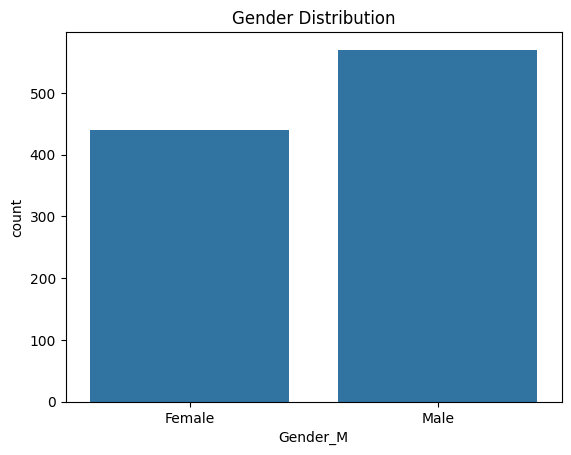

In [22]:
sns.countplot(x="Gender_M", data=df)

plt.xticks([0,1], ["Female", "Male"])
plt.title("Gender Distribution")
plt.show()

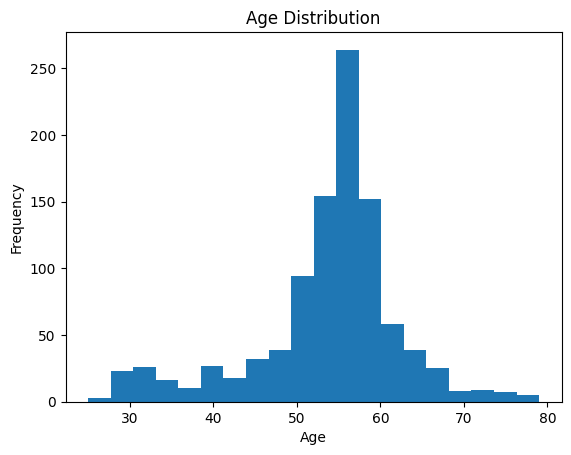

In [24]:
plt.hist(df["AGE"], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

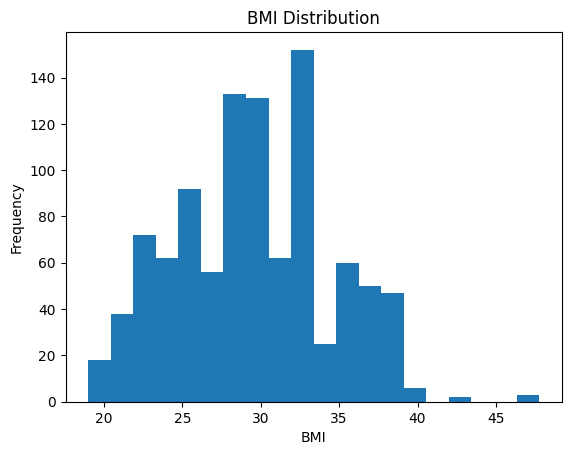

In [26]:
plt.hist(df["BMI"], bins=20)

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.show()

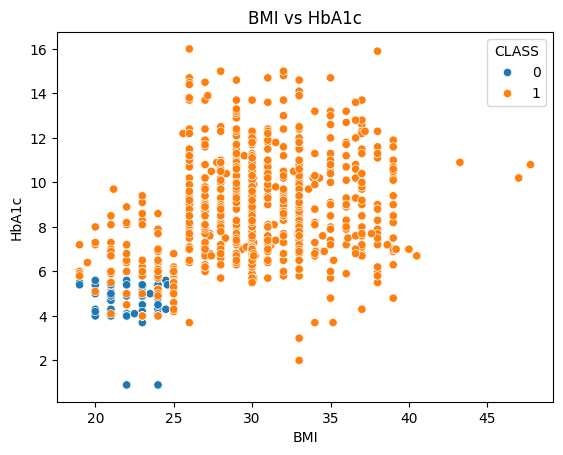

In [28]:
sns.scatterplot(
    x="BMI",
    y="HbA1c",
    hue="CLASS",
    data=df
)

plt.title("BMI vs HbA1c")
plt.show()

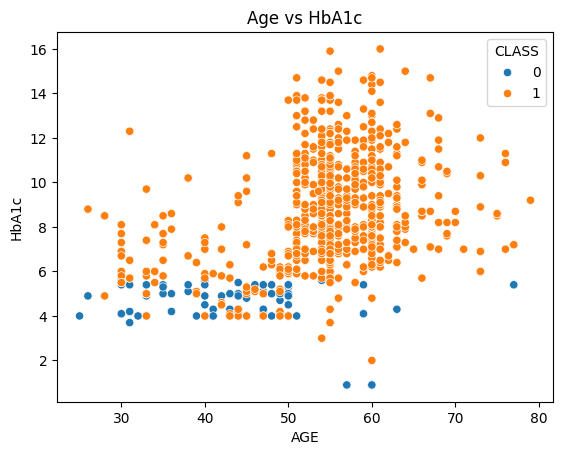

In [30]:
sns.scatterplot(
    x="AGE",
    y="HbA1c",
    hue="CLASS",
    data=df
)

plt.title("Age vs HbA1c")
plt.show()

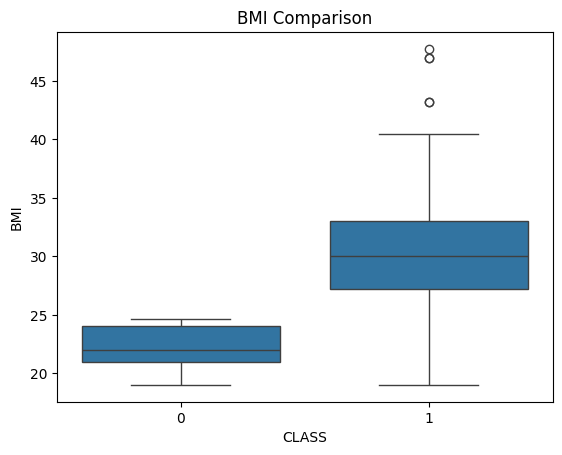

In [32]:
sns.boxplot(x="CLASS", y="BMI", data=df)

plt.title("BMI Comparison")
plt.show()

In [34]:
# features and target
X = df.drop("CLASS", axis=1)

y = df["CLASS"]

In [36]:
from sklearn.model_selection import train_test_split

# split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(706, 11)
(303, 11)


In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [40]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier()
}

In [42]:
results = []

for name, model in models.items():

    # train model
    model.fit(X_train, y_train)

    # predictions
    y_pred = model.predict(X_test)

    # metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # save results
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

# create results dataframe
results_df = pd.DataFrame(results)

results_df

ValueError: Unknown label type: unknown. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

In [44]:
# convert target column to numeric
df["CLASS"] = df["CLASS"].replace({
    "N": 0,
    "P": 1,
    "Y": 1
})

# convert datatype to integer
df["CLASS"] = df["CLASS"].astype(int)

print(df["CLASS"].dtype)
print(df["CLASS"].unique())

int64
[0 1]


In [45]:
X = df.drop("CLASS", axis=1)
y = df["CLASS"]

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [49]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.953795,0.970260,0.977528,0.973881
1,SVM,0.881188,0.881188,1.000000,0.936842
2,Decision Tree,0.990099,0.996241,0.992509,0.994371
3,Random Forest,0.983498,0.985185,0.996255,0.990689
4,KNN,0.927393,0.932862,0.988764,0.960000


as the decsion tree has the higest accurary so we will use it
